#  Rede Neural Perceptron — Classificação de Pureza de Óleo
**CEFET-MG Campus VIII – Varginha**  
**Disciplina:** Laboratório de Inteligência Artificial  
**Professor:** Lázaro Eduardo da Silva  

---
##  Contexto do Problema
A partir da análise de um processo de destilação fracionada de petróleo, um **Perceptron de camada única** é treinado para classificar amostras de óleo em duas classes de pureza:
- **Classe C1** (convenção: `-1`)
- **Classe C2** (convenção: `+1`)

As entradas são $x_1, x_2, x_3$ (propriedades físico-químicas) mais a entrada fixa de bias $x_0 = -1$ (limiar $\theta$).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Configuração de exibição do Pandas e Matplotlib
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

## ️ Implementação da Classe Perceptron

In [4]:
class Perceptron:
    def __init__(self, taxa_aprendizagem=0.01, max_epocas=1000, bias_input=-1):
        self.eta = taxa_aprendizagem
        self.max_epocas = max_epocas
        self.bias_input = bias_input
        self.w = None
        self.w_inicial = None
        self.historico_erros = []
        self.epocas_executadas = 0

    def ativacao(self, u):
        # Função degrau bipolar: g(u) = -1 se u < 0 senão +1
        return np.where(u >= 0, 1.0, -1.0)

    def treinar(self, X, d, seed=None):
        if seed is not None:
            np.random.seed(seed)
        
        n_amostras, n_atributos = X.shape
        # Inicialização aleatória dos pesos entre [0, 1]
        self.w = np.random.rand(n_atributos)
        self.w_inicial = self.w.copy()
        self.historico_erros = []
        self.epocas_executadas = 0
        
        for epoca in range(self.max_epocas):
            erros_na_epoca = 0
            for i in range(n_amostras):
                u = np.dot(self.w, X[i])
                y = self.ativacao(u)
                erro = d[i] - y
                if erro != 0:
                    self.w += self.eta * erro * X[i]
                    erros_na_epoca += 1
            
            self.historico_erros.append(erros_na_epoca)
            self.epocas_executadas += 1
            
            if erros_na_epoca == 0:
                break
                
        return self

    def predizer(self, X):
        u = np.dot(X, self.w)
        return self.ativacao(u)

##  Carregando o Dataset de Treinamento

In [5]:
# Dados de treinamento (30 amostras do anexo)
dados_treino = np.array([
    [-0.6508, 0.1097, 4.0009, -1.0], [-1.4492, 0.8896, 4.4005, -1.0],
    [2.0850, 0.6876, 12.0710, -1.0], [0.2626, 1.1476, 7.7985, 1.0],
    [0.6418, 1.0234, 7.0427, 1.0],   [0.2569, 0.6730, 8.3265, -1.0],
    [1.1155, 0.6043, 7.4446, 1.0],   [0.0914, 0.3399, 7.0677, -1.0],
    [0.0121, 0.5256, 4.6316, 1.0],   [-0.0429, 0.4660, 5.4323, 1.0],
    [0.4340, 0.6870, 8.2287, -1.0],  [0.2735, 1.0287, 7.1934, 1.0],
    [0.4839, 0.4851, 7.4850, -1.0],  [0.4089, -0.1267, 5.5019, -1.0],
    [1.4391, 0.1614, 8.5843, -1.0],  [-0.9115, -0.1973, 2.1962, -1.0],
    [0.3654, 1.0475, 7.4858, 1.0],   [0.2144, 0.7515, 7.1699, 1.0],
    [0.2013, 1.0014, 6.5489, 1.0],   [0.6483, 0.2183, 5.8991, 1.0],
    [-0.1147, 0.2242, 7.2435, -1.0], [-0.7970, 0.8795, 3.8762, 1.0],
    [-1.0625, 0.6366, 2.4707, 1.0],  [0.5307, 0.1285, 5.6883, 1.0],
    [-1.2200, 0.7777, 1.7252, 1.0],  [0.3957, 0.1076, 5.6623, -1.0],
    [-0.1013, 0.5989, 7.1812, -1.0], [2.4482, 0.9455, 11.2095, 1.0],
    [2.0149, 0.6192, 10.9263, -1.0], [0.2012, 0.2611, 5.4631, 1.0]
])

X_raw = dados_treino[:, :3]
d_treino = dados_treino[:, 3]

# Adicionar entrada bias x0 = -1 como primeira coluna
bias_col = np.full((X_raw.shape[0], 1), -1.0)
X_treino = np.hstack((bias_col, X_raw))

print(f"Conjunto de Treinamento: {X_treino.shape[0]} amostras carregadas.")

Conjunto de Treinamento: 30 amostras carregadas.


##  Questões 1 e 2 — Execução e Registro dos 5 Treinamentos

In [6]:
seeds = [1, 2, 3, 4, 5]
modelos = []
tabela_q2 = []

for idx, seed in enumerate(seeds, 1):
    p = Perceptron(taxa_aprendizagem=0.01, max_epocas=1000)
    p.treinar(X_treino, d_treino, seed=seed)
    modelos.append(p)
    
    tabela_q2.append({
        'Treinamento': f'{idx}º (T{idx})',
        'w0 (Inicial)': f'{p.w_inicial[0]:.4f}',
        'w1 (Inicial)': f'{p.w_inicial[1]:.4f}',
        'w2 (Inicial)': f'{p.w_inicial[2]:.4f}',
        'w3 (Inicial)': f'{p.w_inicial[3]:.4f}',
        'w0 (Final)': f'{p.w[0]:.4f}',
        'w1 (Final)': f'{p.w[1]:.4f}',
        'w2 (Final)': f'{p.w[2]:.4f}',
        'w3 (Final)': f'{p.w[3]:.4f}',
        'Número de Épocas': p.epocas_executadas
    })

df_q2 = pd.DataFrame(tabela_q2)
display(df_q2.style.set_caption("Resultados dos 5 Treinamentos do Perceptron"))

,Treinamento,w0 (Inicial),w1 (Inicial),w2 (Inicial),w3 (Inicial),w0 (Final),w1 (Final),w2 (Final),w3 (Final),Número de Épocas
0,1º (T1),0.4170,0.7203,0.0001,0.3023,-3.1030,1.5733,2.5022,-0.7393,404
1,2º (T2),0.4360,0.0259,0.5497,0.4353,-3.0440,1.4792,2.4785,-0.7272,399
2,3º (T3),0.5508,0.7081,0.2909,0.5108,-3.1292,1.5771,2.5154,-0.7440,438
3,4º (T4),0.9670,0.5472,0.9727,0.7148,-3.0530,1.5299,2.4721,-0.7284,426
4,5º (T5),0.2220,0.8707,0.2067,0.9186,-3.1580,1.5962,2.5345,-0.7505,434


##  Questão 3 — Classificação Automática das 10 Amostras de Teste

In [7]:
# 10 amostras de teste fornecidas no enunciado
amostras_teste_raw = np.array([
    [-0.3565,  0.0620, 5.9891],
    [-0.7842,  1.1267, 5.5912],
    [ 0.3012,  0.5611, 5.8234],
    [ 0.7757,  1.0648, 8.0677],
    [ 0.1570,  0.8028, 6.3040],
    [-0.7014,  1.0316, 3.6005],
    [ 0.3748,  0.1536, 6.1537],
    [-0.6920,  0.9404, 4.4058],
    [-1.3970,  0.7141, 4.9263],
    [-1.8842, -0.2805, 1.2548]
])

# Adicionar entrada bias x0 = -1
X_teste = np.hstack((np.full((amostras_teste_raw.shape[0], 1), -1.0), amostras_teste_raw))

# Classificar com os 5 modelos
tabela_q3 = []
for i in range(len(amostras_teste_raw)):
    linha = {
        'Amostra': i + 1,
        'x1': amostras_teste_raw[i, 0],
        'x2': amostras_teste_raw[i, 1],
        'x3': amostras_teste_raw[i, 2]
    }
    saidas = []
    for t, m in enumerate(modelos, 1):
        y = m.predizer(X_teste[i])
        classe_str = 'C1' if y == -1 else 'C2'
        linha[f'T{t}'] = classe_str
        saidas.append(classe_str)
    
    linha['Classe Final'] = 'Classe C1 (-1)' if saidas[0] == 'C1' else 'Classe C2 (+1)'
    tabela_q3.append(linha)

df_q3 = pd.DataFrame(tabela_q3)
display(df_q3.style.set_caption("Resultados da Classificação das 10 Amostras de Óleo"))

,Amostra,x1,x2,x3,T1,T2,T3,T4,T5,Classe Final
0,1,-0.356500,0.062000,5.989100,C1,C1,C1,C1,C1,Classe C1 (-1)
1,2,-0.784200,1.126700,5.591200,C2,C2,C2,C2,C2,Classe C2 (+1)
2,3,0.301200,0.561100,5.823400,C2,C2,C2,C2,C2,Classe C2 (+1)
3,4,0.775700,1.064800,8.067700,C2,C2,C2,C2,C2,Classe C2 (+1)
4,5,0.157000,0.802800,6.304000,C2,C2,C2,C2,C2,Classe C2 (+1)
5,6,-0.701400,1.031600,3.600500,C2,C2,C2,C2,C2,Classe C2 (+1)
6,7,0.374800,0.153600,6.153700,C1,C1,C1,C1,C1,Classe C1 (-1)
7,8,-0.692000,0.940400,4.405800,C2,C2,C2,C2,C2,Classe C2 (+1)
8,9,-1.397000,0.714100,4.926300,C1,C1,C1,C1,C1,Classe C1 (-1)
9,10,-1.884200,-0.280500,1.254800,C1,C1,C1,C1,C1,Classe C1 (-1)


##  Evolução do Erro por Época nos Treinamentos

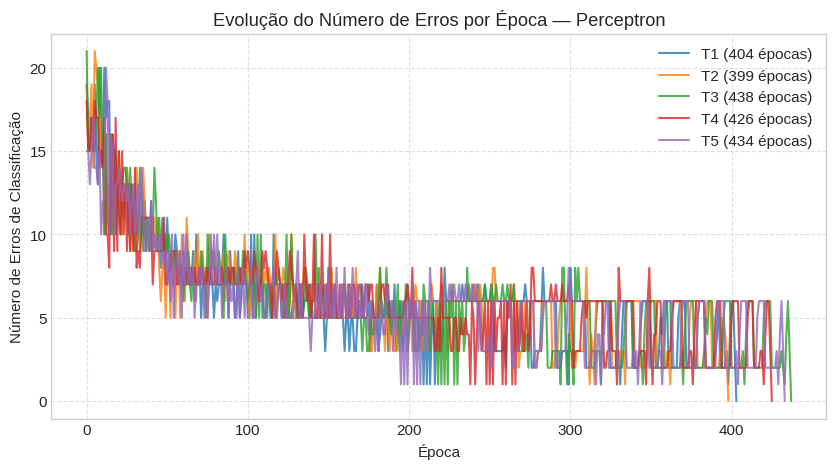

In [8]:
plt.figure(figsize=(10, 5))
for i, m in enumerate(modelos, 1):
    plt.plot(m.historico_erros, label=f'T{i} ({m.epocas_executadas} épocas)', alpha=0.8)

plt.title('Evolução do Número de Erros por Época — Perceptron')
plt.xlabel('Época')
plt.ylabel('Número de Erros de Classificação')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##  Questão 4 — Explicação sobre a Variação do Número de Épocas

**Pergunta:** Explique por que o número de épocas de treinamento varia a cada vez que executamos o treinamento do perceptron.

**Resposta:**  
O número de épocas varia porque em cada execução o vetor de pesos iniciais $[w_0, w_1, w_2, w_3]$ é inicializado com valores aleatórios diferentes.

1. Os pesos iniciais representam o **ponto de partida** do algoritmo no espaço de busca.
2. Pontos de partida mais próximos de um hiperplano separador válido exigem menos ajustes e convergem em menos épocas.
3. Como existem infinitos hiperplanos válidos capazes de separar dados linearmente separáveis, cada vetor inicial conduz a uma trajetória de aprendizado única.

##  Questão 5 — Principal Limitação do Perceptron

**Pergunta:** Qual a principal limitação do perceptron quando aplicado em problemas de classificação de padrões?

**Resposta:**  
A principal limitação do Perceptron simples de camada única é que ele **só consegue resolver problemas cujos padrões sejam LINEARMENTE SEPARÁVEIS**.

Se o problema for não linearmente separável (como a função lógica XOR ou dados sobrepostos):
- O algoritmo do Perceptron entra em loop infinito (nunca atinge erro zero).
- Os pesos continuam oscilando indefinidamente.

Para solucionar problemas não lineares, é necessário utilizar redes neurais multicamadas (**MLP** - Multi-Layer Perceptron) com funções de ativação não lineares.